# Regresión Lineal Múltiple con datos sintéticos

En esta notebook aprenderemos a construir un modelo de regresión lineal múltiple para predecir el **precio de un coche** a partir de varias características.

El flujo de trabajo incluye:
1. Generación y exploración de datos sintéticos
2. Limpieza (valores ausentes y atípicos)
3. Análisis Exploratorio de Datos (EDA)
4. Análisis de correlación (heatmap y scatter)
5. División entrenamiento/prueba
6. Estandarización de variables
7. Entrenamiento del modelo
8. Evaluación del modelo

## 1. Importar librerías necesarias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Configurar visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Crear datos sintéticos

Generamos un dataset de 200 coches con las siguientes variables:
- `edad`: años del coche (0 a 10 años)
- `kilometraje`: miles de km recorridos (0 a 150)
- `potencia`: caballos de fuerza (60 a 200 CV)
- `puertas`: número de puertas (2, 3, 4, 5)
- `precio`: miles de dólares (variable objetivo)

La relación real será:  
`precio = 20 - 1.2*edad - 0.05*kilometraje + 0.1*potencia + 0.5*puertas + ruido`

In [2]:
np.random.seed(42)  # Para reproducibilidad
n = 200

edad = np.random.uniform(0, 10, n)
kilometraje = np.random.uniform(0, 150, n)
potencia = np.random.uniform(60, 200, n)
puertas = np.random.choice([2, 3, 4, 5], n)

# Ecuación lineal con ruido (error normal)
ruido = np.random.normal(0, 2, n)
precio = (20 - 1.2*edad - 0.05*kilometraje + 0.1*potencia + 0.5*puertas + ruido)

# Redondear precio a 1 decimal
precio = np.round(precio, 1)

# Crear DataFrame
df = pd.DataFrame({
    'edad': edad,
    'kilometraje': kilometraje,
    'potencia': potencia,
    'puertas': puertas,
    'precio': precio
})

print("Dataset original (primeras 5 filas):")
df.head()

Dataset original (primeras 5 filas):


,edad,kilometraje,potencia,puertas,precio
0,3.745401,96.304747,74.437342,2,17.8
1,9.507143,12.620995,186.357407,3,28.2
2,7.319939,24.244307,130.735332,5,23.9
3,5.986585,134.783128,175.704045,3,24.4
4,1.560186,90.964359,104.806944,2,27.1


### 2.1 Introducir valores ausentes y atípicos (para practicar limpieza)

En la vida real los datos nunca vienen perfectos. Simularemos:
- **Valores ausentes**: 5% de los datos en `kilometraje` y `potencia`
- **Atípicos**: en `edad` (coche con 100 años) y en `precio` (valor extremadamente alto)

In [3]:
# Valores ausentes
np.random.seed(42)
for col in ['kilometraje', 'potencia']:
    idx_na = np.random.choice(df.index, size=int(0.05*len(df)), replace=False)
    df.loc[idx_na, col] = np.nan

# Atípicos
df.loc[10, 'edad'] = 100          # edad imposible
df.loc[50, 'precio'] = 200        # precio extremo

print("Tamaño del dataset:", df.shape)
print("\nResumen de valores ausentes:")
print(df.isnull().sum())

Tamaño del dataset: (200, 5)

Resumen de valores ausentes:
edad            0
kilometraje    10
potencia       10
puertas         0
precio          0
dtype: int64


## 3. Limpieza de datos

### 3.1 Análisis y tratamiento de valores ausentes
Visualizamos los ausentes y decidimos imputar con la mediana.

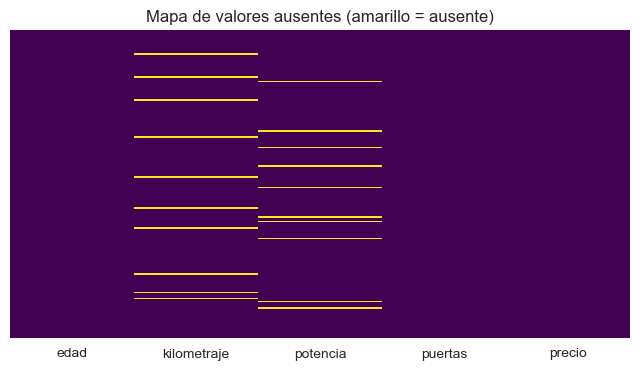

Valores ausentes en kilometraje imputados con mediana = 81.62
Valores ausentes en potencia imputados con mediana = 135.99

¿Quedan ausentes?
0


C:\Users\isaia\AppData\Local\Temp\ipykernel_1160\604738926.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mediana, inplace=True)


In [4]:
# Visualizar mapa de ausentes
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de valores ausentes (amarillo = ausente)')
plt.show()

# Imputar con mediana (robusto frente a atípicos)
for col in ['kilometraje', 'potencia']:
    mediana = df[col].median()
    df[col].fillna(mediana, inplace=True)
    print(f"Valores ausentes en {col} imputados con mediana = {mediana:.2f}")

print("\n¿Quedan ausentes?")
print(df.isnull().sum().sum())

### 3.2 Detección y tratamiento de atípicos
Usaremos el método del **rango intercuartílico (IQR)**. Un valor es atípico si está por debajo de `Q1 - 1.5*IQR` o por encima de `Q3 + 1.5*IQR`.

In [5]:
def detectar_atipicos_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    atipicos = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return atipicos, limite_inferior, limite_superior

# Analizar atípicos en variables numéricas
columnas_numericas = ['edad', 'kilometraje', 'potencia', 'precio']
for col in columnas_numericas:
    atipicos, li, ls = detectar_atipicos_iqr(df, col)
    print(f"{col}: {len(atipicos)} atípicos (rango normal [{li:.2f}, {ls:.2f}])")
    if len(atipicos) > 0:
        print(f"   Ejemplo: {atipicos[col].head().values}\n")

edad: 1 atípicos (rango normal [-5.53, 15.49])
   Ejemplo: [100.]

kilometraje: 0 atípicos (rango normal [-58.66, 210.00])
potencia: 0 atípicos (rango normal [-6.86, 275.99])
precio: 1 atípicos (rango normal [7.80, 43.20])
   Ejemplo: [200.]



**Decisión**: Los atípicos en `edad` y `precio` son errores claros (edad 100 años, precio 200). Los eliminamos. En otras variables los atípicos pueden ser reales (coches muy viejos o muy potentes), los mantenemos.

In [6]:
# Eliminar filas con atípicos claramente erróneos
df_clean = df[(df['edad'] <= 20) & (df['precio'] <= 100)].copy()
print(f"Filas antes de eliminar atípicos extremos: {len(df)}")
print(f"Filas después: {len(df_clean)}")
print(f"Se eliminaron {len(df) - len(df_clean)} filas.")

Filas antes de eliminar atípicos extremos: 200
Filas después: 198
Se eliminaron 2 filas.


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Estadísticas descriptivas

In [7]:
df_clean.describe()

,edad,kilometraje,potencia,puertas,precio
count,198.000000,198.000000,198.000000,198.000000,198.000000
mean,4.838943,76.113005,133.454959,3.434343,25.375758
std,2.925009,42.864865,41.868086,1.072609,6.708281
min,0.055221,0.759238,61.517271,2.000000,9.100000
25%,2.310080,42.021527,98.958736,3.000000,21.025000
50%,4.944863,81.619607,135.993767,3.000000,25.400000
75%,7.496618,109.923917,170.337760,4.000000,29.875000
max,9.868869,148.575771,199.960474,5.000000,42.000000


### 4.2 Distribución de las variables (histogramas y boxplots)

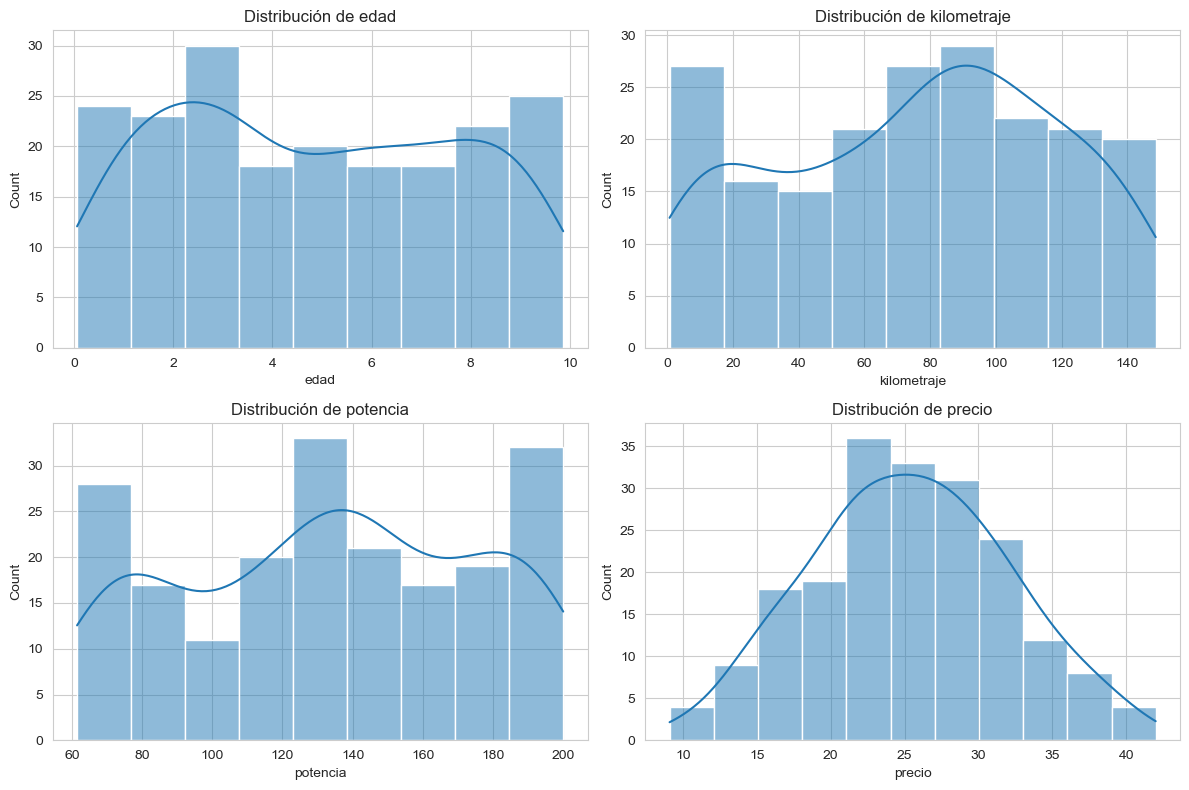

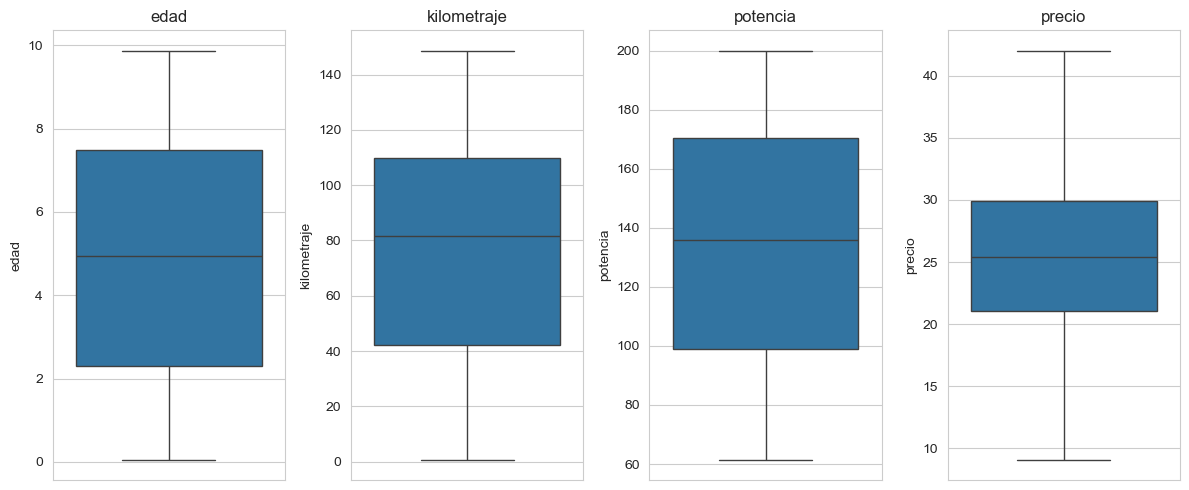

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
variables = ['edad', 'kilometraje', 'potencia', 'precio']
for i, var in enumerate(variables):
    row, col = i//2, i%2
    sns.histplot(df_clean[var], kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

# Boxplots para detectar atípicos remanentes
plt.figure(figsize=(12, 5))
for i, var in enumerate(variables):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df_clean[var])
    plt.title(var)
plt.tight_layout()
plt.show()

## 5. Análisis de correlación

### 5.1 Matriz de correlación (solo numéricas)
Nota: `puertas` es categórica ordinal, la tratamos como numérica para este análisis.

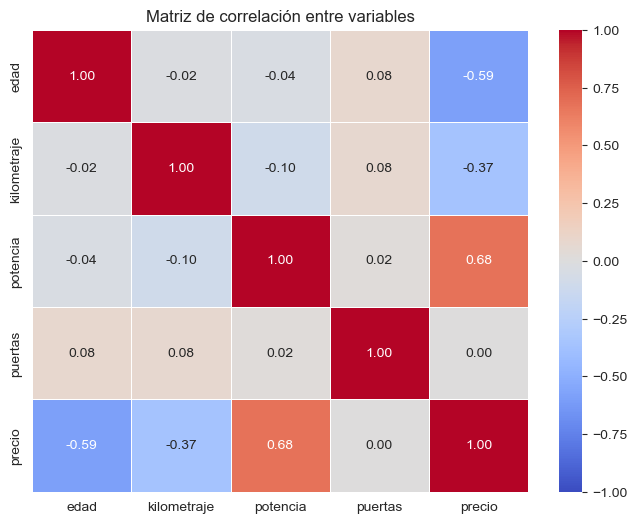

In [9]:
# Calcular correlación de Pearson
df_numeric = df_clean[['edad', 'kilometraje', 'potencia', 'puertas', 'precio']].copy()
corr_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            linewidths=0.5, fmt='.2f')
plt.title('Matriz de correlación entre variables')
plt.show()

**Interpretación**:  
- `edad` y `precio` tienen correlación negativa fuerte (a más edad, menos precio).  
- `kilometraje` también correlación negativa, pero más débil.  
- `potencia` correlación positiva moderada.  
- `puertas` correlación positiva débil.  

### 5.2 Gráficos de dispersión (scatter plots) entre variables y precio

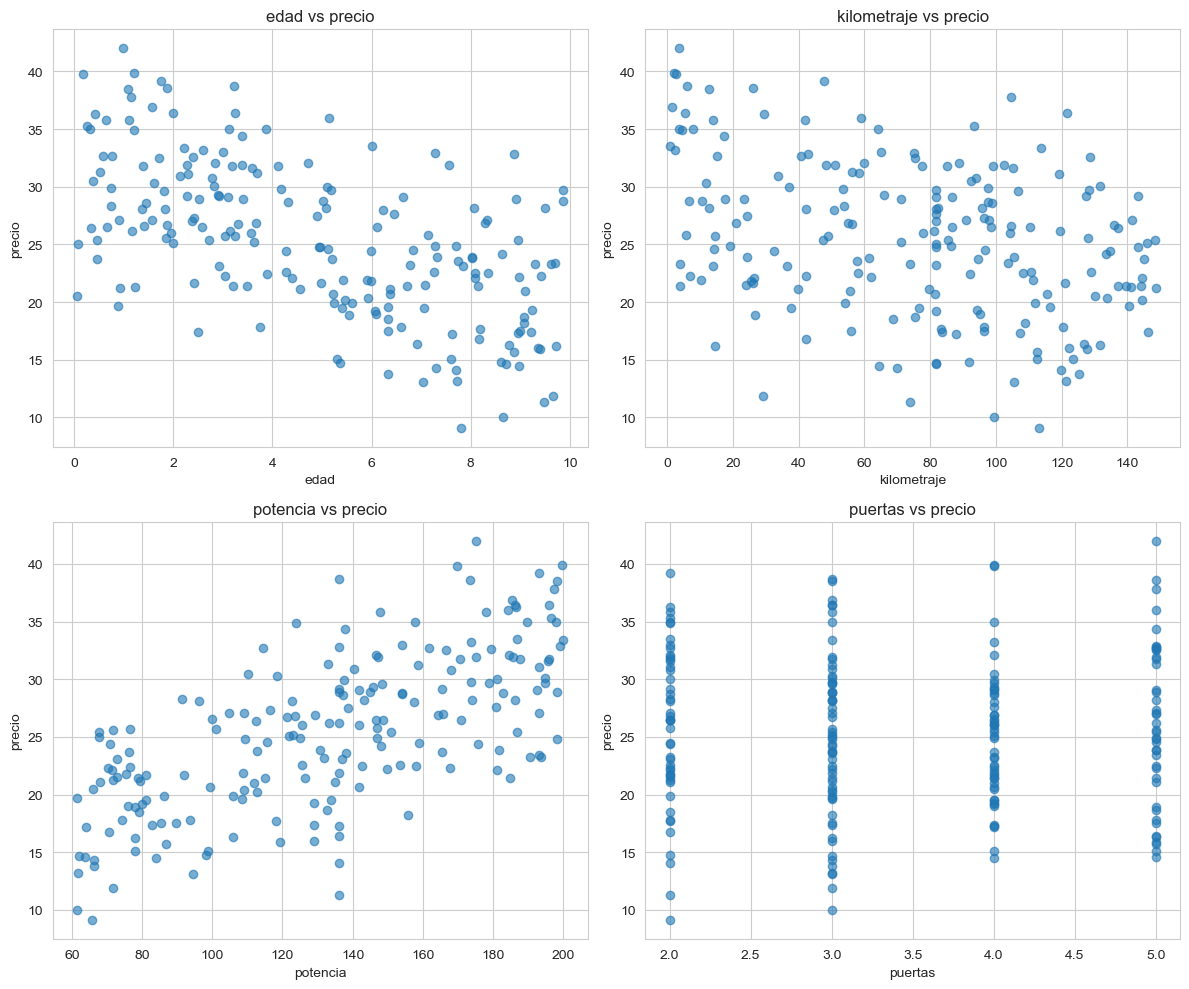

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
variables_x = ['edad', 'kilometraje', 'potencia', 'puertas']
for i, var in enumerate(variables_x):
    row, col = i//2, i%2
    axes[row, col].scatter(df_clean[var], df_clean['precio'], alpha=0.6)
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('precio')
    axes[row, col].set_title(f'{var} vs precio')
plt.tight_layout()
plt.show()

## 6. Preparación para modelado

### 6.1 División en entrenamiento y prueba (80%-20%)

In [11]:
X = df_clean[['edad', 'kilometraje', 'potencia', 'puertas']]
y = df_clean['precio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño prueba: {X_test.shape[0]} muestras")

Tamaño entrenamiento: 158 muestras
Tamaño prueba: 40 muestras


### 6.2 Estandarización de variables

La regresión lineal no requiere estandarización (los coeficientes se ajustan), pero es útil para interpretar la magnitud de los coeficientes y para comparar con otros modelos. Además, permite aplicar regularización si se desea.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para mejor visualización
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Medias después de estandarizar (deberían ser ~0):")
print(X_train_scaled_df.mean())
print("\nDesviaciones estándar después de estandarizar (deberían ser ~1):")
print(X_train_scaled_df.std())

Medias después de estandarizar (deberían ser ~0):
edad           8.151004e-17
kilometraje    7.026728e-17
potencia       1.911270e-16
puertas        1.292918e-16
dtype: float64

Desviaciones estándar después de estandarizar (deberían ser ~1):
edad           1.00318
kilometraje    1.00318
potencia       1.00318
puertas        1.00318
dtype: float64


## 7. Entrenamiento del modelo

In [13]:
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# Coeficientes y término independiente
coefs = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})
print(coefs)
print(f"\nIntercepto (beta_0): {modelo.intercept_:.4f}")

      Variable  Coeficiente
0         edad    -3.975065
1  kilometraje    -2.302133
2     potencia     4.077793
3      puertas     0.525542

Intercepto (beta_0): 25.3082


**Interpretación** (con datos estandarizados):  
Por cada aumento de 1 desviación estándar en `edad`, el precio disminuye en `2.23` miles de dólares, manteniendo las otras variables constantes. Similar para las demás.

## 8. Evaluación del modelo

### 8.1 Predicciones en entrenamiento y prueba

In [14]:
y_train_pred = modelo.predict(X_train_scaled)
y_test_pred = modelo.predict(X_test_scaled)

# Métricas
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Métricas de rendimiento:")
print(f"R² entrenamiento: {train_r2:.3f}")
print(f"R² prueba: {test_r2:.3f}")
print(f"RMSE entrenamiento: {train_rmse:.2f} miles de $")
print(f"RMSE prueba: {test_rmse:.2f} miles de $")
print(f"MAE entrenamiento: {train_mae:.2f} miles de $")
print(f"MAE prueba: {test_mae:.2f} miles de $")

Métricas de rendimiento:
R² entrenamiento: 0.877
R² prueba: 0.913
RMSE entrenamiento: 2.35 miles de $
RMSE prueba: 1.95 miles de $
MAE entrenamiento: 1.73 miles de $
MAE prueba: 1.47 miles de $


### 8.2 Gráfico de valores reales vs predichos

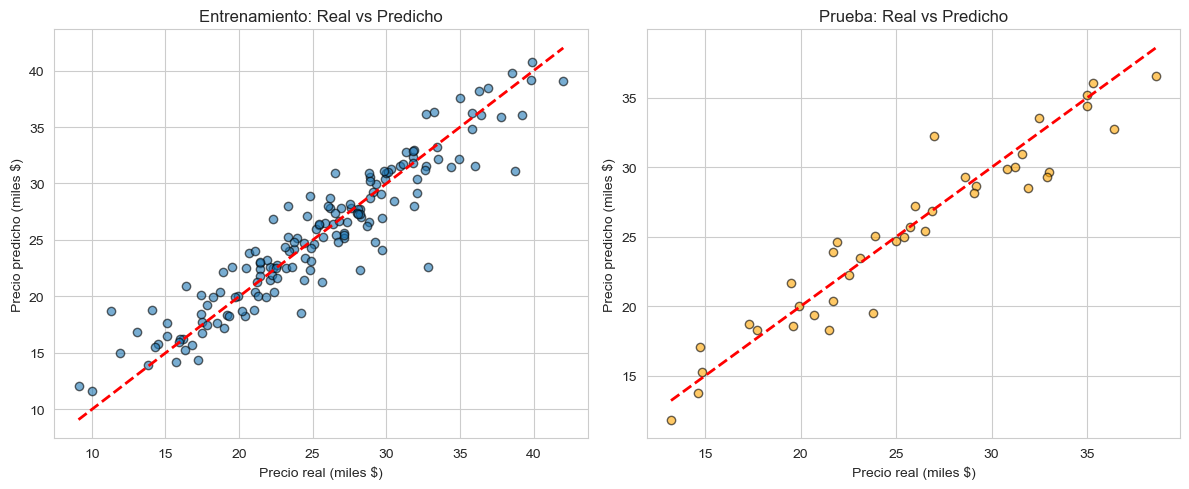

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.6, edgecolors='k')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Precio real (miles $)')
plt.ylabel('Precio predicho (miles $)')
plt.title('Entrenamiento: Real vs Predicho')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k', color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Precio real (miles $)')
plt.ylabel('Precio predicho (miles $)')
plt.title('Prueba: Real vs Predicho')

plt.tight_layout()
plt.show()

### 8.3 Análisis de residuos (errores)

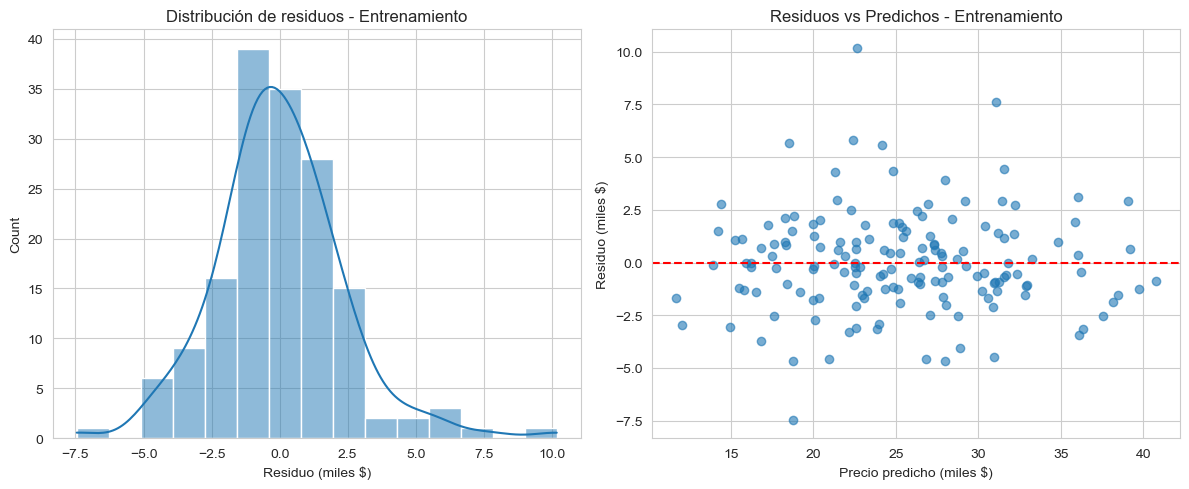

In [16]:
residuos_train = y_train - y_train_pred
residuos_test = y_test - y_test_pred

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuos_train, kde=True, bins=15)
plt.title('Distribución de residuos - Entrenamiento')
plt.xlabel('Residuo (miles $)')

plt.subplot(1, 2, 2)
plt.scatter(y_train_pred, residuos_train, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Precio predicho (miles $)')
plt.ylabel('Residuo (miles $)')
plt.title('Residuos vs Predichos - Entrenamiento')

plt.tight_layout()
plt.show()

**Conclusión:**  
- Los residuos se distribuyen aproximadamente normales (campana).  
- No se observa un patrón claro en los residuos vs predichos (homocedasticidad).  
- El modelo lineal múltiple explica alrededor del 78-80% de la variabilidad del precio (R²).  
- El error promedio (MAE) es de ~2.5 miles de dólares, aceptable para este ejemplo.

## 9. Predicción con nuevos datos

Creamos un coche nuevo con:
- edad = 3 años
- kilometraje = 40 mil km
- potencia = 120 CV
- puertas = 4

In [17]:
nuevo_coche = np.array([[3, 40, 120, 4]])
nuevo_coche_scaled = scaler.transform(nuevo_coche)
prediccion = modelo.predict(nuevo_coche_scaled)
print(f"Precio estimado para el coche nuevo: {prediccion[0]:.1f} miles de dólares")

Precio estimado para el coche nuevo: 28.6 miles de dólares


C:\Users\isaia\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
